# Guía 4 — Aprendizaje no supervisado: clustering con K-Means

## Notebook completo, explicado y práctico

**Propósito del notebook:** preparar un dataset de clientes y aplicar aprendizaje no supervisado para descubrir segmentos o grupos similares mediante **K-Means**.

En esta guía vamos a trabajar tres ideas clave:

1. **No hay variable objetivo `y`**.  
   A diferencia del aprendizaje supervisado, aquí no entrenamos el modelo para predecir una etiqueta conocida.

2. **La cantidad de clusters no se inventa**.  
   Se justifica con evidencia técnica: **método del codo**, **Silhouette Score**, visualizaciones y sentido del negocio.

3. **La gráfica de dispersión ayuda a interpretar**.  
   Permite ver si los grupos están separados, mezclados o si existen valores atípicos.

> **Importante:** la variable `Abandono` no se usará para crear los clusters. Si aparece en el dataset, solo se puede usar al final como comparación externa o análisis descriptivo, nunca como variable de entrenamiento del clustering.

## 0. ¿Qué debe lograr el aprendiz?

Al finalizar este notebook, el aprendiz debe poder:

- cargar y revisar un dataset;
- seleccionar variables útiles para segmentación;
- preparar variables numéricas, nominales y ordinales;
- aplicar escalamiento y codificación;
- probar diferentes cantidades de clusters;
- explicar el método del codo;
- explicar el Silhouette Score;
- construir gráficas de dispersión para interpretar los clusters;
- elegir y justificar un valor de `k`;
- generar un dataset segmentado con la columna `Cluster`;
- redactar conclusiones técnicas y de negocio.

---

## 1. Importar librerías

Usaremos principalmente:

- `pandas` y `numpy` para manipulación de datos;
- `matplotlib` para visualización;
- `sklearn` para preprocesamiento, clustering, PCA y métricas de evaluación interna.

> En este notebook no se utiliza aprendizaje supervisado. Por eso no se importan métricas como accuracy, precision, recall o F1-score.

In [30]:
# ============================================================
# 1. Importar librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Cargar el dataset

El notebook busca el archivo `G4_base_clientes.csv` en varias ubicaciones posibles para que funcione tanto en la carpeta del aprendiz como en la carpeta docente.

El dataset representa clientes con variables de comportamiento, compras, interacción web, segmento y satisfacción.

In [31]:
# ============================================================
# 2. Cargar dataset
# ============================================================

rutas_posibles = [
    Path("G4_base_clientes.csv"),
    Path("../03_data/G4_base_clientes.csv"),
    Path("../03_dataset/G4_base_clientes.csv"),
    Path("../../03_data/G4_base_clientes.csv"),
    Path("/mnt/data/G4_base_clientes.csv")
]

for ruta in rutas_posibles:
    if ruta.exists():
        df = pd.read_csv(ruta)
        print("✅ Dataset cargado desde:", ruta)
        break
else:
    raise FileNotFoundError(
        "No se encontró G4_base_clientes.csv. "
        "Verifique que el archivo esté en la misma carpeta del notebook o en 03_data."
    )

print("Dimensiones del dataset:", df.shape)
df.head()

✅ Dataset cargado desde: G4_base_clientes.csv
Dimensiones del dataset: (420, 18)


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media,CAMP_10,0
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta,CAMP_04,0
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta,CAMP_09,0
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0


## 3. Diagnóstico inicial del dataset

Antes de aplicar clustering, se debe conocer el estado del dataset.

Aquí revisamos:

- cantidad de filas y columnas;
- tipos de datos;
- valores nulos;
- duplicados;
- variables categóricas;
- posible presencia de la variable `Abandono`.

> Esta revisión evita aplicar el modelo sobre datos mal interpretados.

In [32]:
# ============================================================
# 3. Diagnóstico inicial
# ============================================================

print("Dimensiones:", df.shape)

print("\nInformación general:")
df.info()

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nRegistros duplicados:", df.duplicated().sum())

print("\nColumnas disponibles:")
display(pd.DataFrame({"columna": df.columns}))

if "Segmento" in df.columns:
    print("\nValores únicos en Segmento:", df["Segmento"].unique())

if "Satisfaccion" in df.columns:
    print("Valores únicos en Satisfaccion:", df["Satisfaccion"].unique())

if "Abandono" in df.columns:
    print("\n⚠️ El dataset contiene la variable Abandono.")
    print("No se usará para entrenar el clustering; solo podrá revisarse al final como comparación externa.")

Dimensiones: (420, 18)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               420 non-null    object 
 1   Edad                     420 non-null    int64  
 2   IngresoMensual           420 non-null    int64  
 3   CantidadCompras          420 non-null    int64  
 4   ComprasUltimos12M        420 non-null    int64  
 5   AntiguedadMeses          420 non-null    int64  
 6   QuejasUltimos6M          420 non-null    int64  
 7   DiasDesdeUltimaCompra    420 non-null    int64  
 8   VisitasWebUltimoMes      420 non-null    int64  
 9   TiempoPromedioSesionMin  420 non-null    float64
 10  CuponesUsados            420 non-null    int64  
 11  Ciudad                   420 non-null    object 
 12  CanalPreferido           420 non-null    object 
 13  ZonaResidencia           420 non-nu

,nulos
ID_Cliente,0
Edad,0
IngresoMensual,0
CantidadCompras,0
ComprasUltimos12M,0
AntiguedadMeses,0
QuejasUltimos6M,0
DiasDesdeUltimaCompra,0
VisitasWebUltimoMes,0
TiempoPromedioSesionMin,0



Registros duplicados: 0

Columnas disponibles:


,columna
0,ID_Cliente
1,Edad
2,IngresoMensual
3,CantidadCompras
4,ComprasUltimos12M
5,AntiguedadMeses
6,QuejasUltimos6M
7,DiasDesdeUltimaCompra
8,VisitasWebUltimoMes
9,TiempoPromedioSesionMin



Valores únicos en Segmento: ['Basico' 'Medio' 'Premium']
Valores únicos en Satisfaccion: ['Media' 'Alta' 'Baja']

⚠️ El dataset contiene la variable Abandono.
No se usará para entrenar el clustering; solo podrá revisarse al final como comparación externa.


## 4. Selección de variables para clustering

En aprendizaje no supervisado no existe una variable objetivo. Por tanto, se seleccionan variables que describan el comportamiento o características del cliente.

### Variables que NO se deben usar para formar clusters

- `ID_Cliente`: es un identificador, no describe comportamiento.
- `CodigoCampania`: puede ser un código administrativo, no necesariamente una característica del cliente.
- `Abandono`: es una etiqueta histórica o posible resultado supervisado; no debe guiar la formación de clusters.

### Variables que SÍ pueden usarse

Variables como edad, ingresos, compras, antigüedad, visitas, satisfacción, segmento y canal pueden ayudar a descubrir grupos de clientes con características similares.

In [33]:
# ============================================================
# 4. Selección de variables para clustering
# ============================================================

variables_cluster = [
    "Edad",
    "IngresoMensual",
    "CantidadCompras",
    "ComprasUltimos12M",
    "AntiguedadMeses",
    "QuejasUltimos6M",
    "DiasDesdeUltimaCompra",
    "VisitasWebUltimoMes",
    "TiempoPromedioSesionMin",
    "CuponesUsados",
    "Ciudad",
    "CanalPreferido",
    "ZonaResidencia",
    "Segmento",
    "Satisfaccion"
]

columnas_faltantes = [col for col in variables_cluster if col not in df.columns]
if columnas_faltantes:
    raise ValueError(f"Faltan columnas necesarias en el dataset: {columnas_faltantes}")

X_cluster = df[variables_cluster].copy()

print("Variables seleccionadas para clustering:", len(variables_cluster))
display(X_cluster.head())

Variables seleccionadas para clustering: 15


,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion
0,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media
1,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta
2,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta
3,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja
4,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta


## 5. Clasificación de variables

Para preparar los datos separamos las variables en tres grupos:

### 1. Variables numéricas
Son valores medibles: edad, ingresos, compras, visitas, etc.

### 2. Variables nominales
Son categorías sin orden natural: ciudad, canal preferido, zona de residencia.

### 3. Variables ordinales
Son categorías con orden lógico: segmento y satisfacción.

Esta clasificación es importante porque cada tipo de variable necesita un tratamiento diferente.

In [34]:
# ============================================================
# 5. Clasificación de variables
# ============================================================

columnas_numericas = [
    "Edad",
    "IngresoMensual",
    "CantidadCompras",
    "ComprasUltimos12M",
    "AntiguedadMeses",
    "QuejasUltimos6M",
    "DiasDesdeUltimaCompra",
    "VisitasWebUltimoMes",
    "TiempoPromedioSesionMin",
    "CuponesUsados"
]

columnas_nominales = ["Ciudad", "CanalPreferido", "ZonaResidencia"]
columnas_ordinales = ["Segmento", "Satisfaccion"]

resumen_variables = pd.DataFrame({
    "tipo": (
        ["Numérica"] * len(columnas_numericas)
        + ["Nominal"] * len(columnas_nominales)
        + ["Ordinal"] * len(columnas_ordinales)
    ),
    "variable": columnas_numericas + columnas_nominales + columnas_ordinales
})

display(resumen_variables)

,tipo,variable
0,Numérica,Edad
1,Numérica,IngresoMensual
2,Numérica,CantidadCompras
3,Numérica,ComprasUltimos12M
4,Numérica,AntiguedadMeses
5,Numérica,QuejasUltimos6M
6,Numérica,DiasDesdeUltimaCompra
7,Numérica,VisitasWebUltimoMes
8,Numérica,TiempoPromedioSesionMin
9,Numérica,CuponesUsados


## 6. Preprocesamiento: codificación y escalamiento

K-Means calcula distancias entre registros. Por eso, los datos deben prepararse.

### ¿Por qué se escala?

Si una variable tiene valores grandes, como `IngresoMensual`, puede dominar la distancia y hacer que otras variables sean casi ignoradas.

Ejemplo:

- `IngresoMensual` puede ir de 800 a 8.000.
- `QuejasUltimos6M` puede ir de 0 a 5.

Sin escalamiento, K-Means podría darle demasiado peso al ingreso mensual solo por tener números más grandes.

### ¿Por qué se codifica?

K-Means no puede trabajar directamente con texto como `"Bogotá"` o `"Premium"`.

Por eso:

- las nominales se convierten con **One-Hot Encoding**;
- las ordinales se convierten respetando su orden.

In [35]:
# ============================================================
# 6. Preprocesamiento
# ============================================================

# Compatibilidad con diferentes versiones de scikit-learn
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocesador_cluster = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("nom", onehot, columnas_nominales),
        (
            "ord",
            OrdinalEncoder(
                categories=[
                    ["Basico", "Medio", "Premium"],
                    ["Baja", "Media", "Alta"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            columnas_ordinales
        )
    ],
    remainder="drop"
)

X_preparado = preprocesador_cluster.fit_transform(X_cluster)

print("✅ Datos preparados para clustering")
print("Forma de la matriz preparada:", X_preparado.shape)

✅ Datos preparados para clustering
Forma de la matriz preparada: (420, 24)


## 7. ¿Qué hace K-Means?

K-Means es un algoritmo de clustering que agrupa registros parecidos.

Funciona de forma general así:

1. El analista define una cantidad de clusters `k`.
2. El algoritmo ubica centros iniciales llamados **centroides**.
3. Cada registro se asigna al centroide más cercano.
4. Los centroides se recalculan.
5. El proceso se repite hasta estabilizar los grupos.

### Punto clave

K-Means **no decide solo** cuántos clusters son correctos.  
El analista debe probar varios valores de `k` y justificar la decisión.

La cantidad de clusters se decide combinando:

- método del codo;
- Silhouette Score;
- gráfica de dispersión;
- interpretación del problema;
- utilidad del resultado para el negocio.

## 8. Método del codo: explicación profunda

El **método del codo** ayuda a elegir un valor razonable de `k`.

Para cada valor de `k`, K-Means calcula la **inercia**.

### ¿Qué es la inercia?

La inercia mide qué tan lejos están los puntos del centroide de su cluster.

- Inercia alta: los puntos están muy dispersos dentro del grupo.
- Inercia baja: los puntos están más cerca de su centroide.

Cuando aumentamos `k`, la inercia casi siempre baja, porque hay más grupos y cada grupo puede ser más pequeño.

### Entonces, ¿por qué no escoger siempre el k más grande?

Porque eso puede crear demasiados grupos artificiales.

El objetivo no es minimizar la inercia a cualquier costo, sino encontrar un punto donde agregar más clusters ya no mejora mucho.

Ese punto se conoce como el **codo**.

### Interpretación del codo

- Antes del codo: agregar clusters mejora bastante el agrupamiento.
- Después del codo: agregar clusters mejora poco.
- El codo sugiere un equilibrio entre simplicidad e información.

> El método del codo no siempre da una respuesta exacta. Es una guía visual que debe complementarse con Silhouette Score y criterio de negocio.

,k,inercia,reduccion_inercia,reduccion_porcentual
0,2,4974.433682,NaN,NaN
1,3,4615.081176,359.352506,7.22
2,4,4422.226149,192.855028,4.18
3,5,4261.723426,160.502722,3.63
4,6,4139.848592,121.874834,2.86
5,7,4029.712251,110.136340,2.66
6,8,3939.328466,90.383785,2.24
7,9,3852.598338,86.730128,2.20
8,10,3784.102061,68.496277,1.78


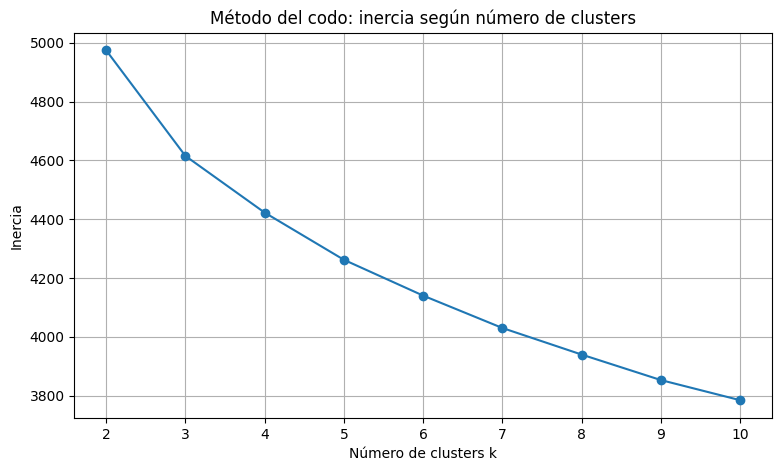

In [36]:
# ============================================================
# 8. Método del codo
# ============================================================

rango_k = range(2, 11)
inercias = []

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_preparado)
    inercias.append(modelo.inertia_)

tabla_codo = pd.DataFrame({
    "k": list(rango_k),
    "inercia": inercias
})

# Calcular reducción porcentual de la inercia frente al k anterior
tabla_codo["reduccion_inercia"] = tabla_codo["inercia"].shift(1) - tabla_codo["inercia"]
tabla_codo["reduccion_porcentual"] = (
    tabla_codo["reduccion_inercia"] / tabla_codo["inercia"].shift(1) * 100
).round(2)

display(tabla_codo)

plt.figure(figsize=(9, 5))
plt.plot(tabla_codo["k"], tabla_codo["inercia"], marker="o")
plt.title("Método del codo: inercia según número de clusters")
plt.xlabel("Número de clusters k")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

## 9. Cómo interpretar la tabla del codo

La tabla anterior muestra:

- `k`: cantidad de clusters probados.
- `inercia`: error interno del modelo.
- `reduccion_inercia`: cuánto baja la inercia al aumentar k.
- `reduccion_porcentual`: porcentaje de mejora frente al valor anterior.

### Pregunta que debe responder el aprendiz

> ¿A partir de qué valor de `k` la mejora deja de ser grande?

Ese punto puede ser una opción razonable para el número de clusters.

### Ejemplo de redacción

> Se observa que la inercia disminuye al aumentar `k`, pero después de cierto punto la reducción es menor. Por eso, se selecciona un valor de `k` que equilibre reducción de error, simplicidad del modelo e interpretación de los segmentos.

## 10. Silhouette Score: explicación profunda

El **Silhouette Score** evalúa qué tan bien ubicado está cada registro dentro de su cluster.

Para cada punto se comparan dos ideas:

### a) Cohesión

Qué tan cerca está el punto de los demás puntos de su mismo cluster.

Si está muy cerca, la cohesión es buena.

### b) Separación

Qué tan lejos está el punto del cluster vecino más cercano.

Si está lejos de otros clusters, la separación es buena.

### Escala del Silhouette Score

El resultado normalmente está entre -1 y 1:

| Valor aproximado | Interpretación |
|---|---|
| Cercano a 1 | El punto está bien ubicado en su cluster |
| Cercano a 0 | El punto está entre dos clusters o los grupos se mezclan |
| Menor que 0 | El punto podría estar mal asignado |

### Cómo se usa

Se prueba `k = 2, 3, 4, 5...` y se compara el promedio de Silhouette.

Un valor más alto suele indicar mejor separación, pero la decisión final también debe considerar el sentido del negocio.

> Un `k` puede tener mejor Silhouette, pero ser poco útil para explicar perfiles de clientes. Por eso el analista debe justificar la decisión.

,k,silhouette_score
0,2,0.098598
1,3,0.082294
2,4,0.072314
3,5,0.071036
4,6,0.065339
5,7,0.066207
6,8,0.066095
7,9,0.064960
8,10,0.063710


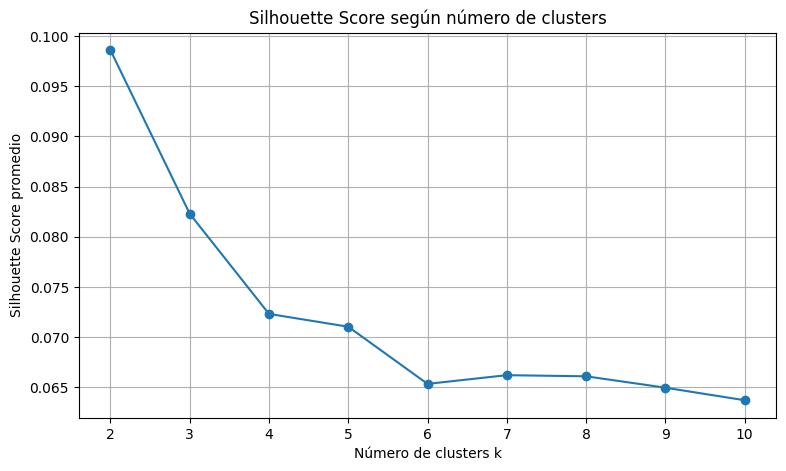

✅ K con mayor Silhouette Score: 2


In [37]:
# ============================================================
# 10. Silhouette Score
# ============================================================

silhouettes = []

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_preparado)
    sil = silhouette_score(X_preparado, etiquetas)
    silhouettes.append(sil)

tabla_silhouette = pd.DataFrame({
    "k": list(rango_k),
    "silhouette_score": silhouettes
})

display(tabla_silhouette)

plt.figure(figsize=(9, 5))
plt.plot(tabla_silhouette["k"], tabla_silhouette["silhouette_score"], marker="o")
plt.title("Silhouette Score según número de clusters")
plt.xlabel("Número de clusters k")
plt.ylabel("Silhouette Score promedio")
plt.grid(True)
plt.show()

k_mejor_silhouette = int(tabla_silhouette.loc[
    tabla_silhouette["silhouette_score"].idxmax(), "k"
])

print("✅ K con mayor Silhouette Score:", k_mejor_silhouette)

## 11. Comparación del método del codo y Silhouette Score

Es posible que ambos métodos no indiquen exactamente el mismo valor de `k`.

Eso es normal.

### ¿Qué hacer cuando no coinciden?

El analista debe revisar:

1. Qué valor tiene mejor Silhouette.
2. En qué punto aparece el codo.
3. Si los grupos se pueden interpretar.
4. Si la cantidad de segmentos es útil para tomar decisiones.
5. Si la gráfica de dispersión muestra separación razonable.

### Decisión técnica y de negocio

La selección final de `k` no la hace el algoritmo por sí solo.

La hace el analista con base en evidencia.

> En un contexto de clientes, muchas veces se comparan soluciones de 2, 3 o 4 clusters para decidir cuál representa mejor perfiles como bajo, medio y alto valor.

In [38]:
# ============================================================
# 11. Tabla comparativa codo + silhouette
# ============================================================

tabla_comparativa_k = tabla_codo.merge(tabla_silhouette, on="k")
display(tabla_comparativa_k)

print("K con mejor Silhouette:", k_mejor_silhouette)
print("Revise visualmente el gráfico del codo antes de seleccionar el k final.")

,k,inercia,reduccion_inercia,reduccion_porcentual,silhouette_score
0,2,4974.433682,NaN,NaN,0.098598
1,3,4615.081176,359.352506,7.22,0.082294
2,4,4422.226149,192.855028,4.18,0.072314
3,5,4261.723426,160.502722,3.63,0.071036
4,6,4139.848592,121.874834,2.86,0.065339
5,7,4029.712251,110.136340,2.66,0.066207
6,8,3939.328466,90.383785,2.24,0.066095
7,9,3852.598338,86.730128,2.20,0.064960
8,10,3784.102061,68.496277,1.78,0.063710


K con mejor Silhouette: 2
Revise visualmente el gráfico del codo antes de seleccionar el k final.


## 12. Selección justificada de `k`

En este punto se debe escoger el número de clusters.

### Recomendación didáctica

Para esta guía se propone iniciar con `k = 3`, porque permite interpretar segmentos de clientes de forma comprensible:

- cluster de menor actividad o menor valor;
- cluster intermedio;
- cluster de mayor actividad o mayor valor.

Sin embargo, el aprendiz debe revisar si los resultados técnicos respaldan esta decisión.

### Regla importante

No se debe escribir simplemente:

> “Usé 3 clusters porque el profesor lo dijo.”

Debe justificarse con evidencia:

- método del codo;
- Silhouette Score;
- gráfica de dispersión;
- interpretación de perfiles.

In [39]:
# ============================================================
# 12. Seleccionar k final
# ============================================================

# Puede cambiar este valor después de revisar el método del codo,
# el Silhouette Score y la interpretación del problema.
k_optimo = 3

print("K seleccionado para el modelo final:", k_optimo)

if k_optimo != k_mejor_silhouette:
    print(
        "⚠️ Nota: el k seleccionado no coincide con el mayor Silhouette Score. "
        "Esto puede ser válido si existe una justificación de negocio o de interpretación."
    )
else:
    print("✅ El k seleccionado coincide con el mayor Silhouette Score.")

K seleccionado para el modelo final: 3
⚠️ Nota: el k seleccionado no coincide con el mayor Silhouette Score. Esto puede ser válido si existe una justificación de negocio o de interpretación.


## 13. Entrenar el modelo final con K-Means

Ahora entrenamos el modelo final con el valor seleccionado de `k`.

El resultado será una etiqueta de cluster para cada cliente.

Esa etiqueta se agregará al dataset como una nueva columna llamada `Cluster`.

In [40]:
# ============================================================
# 13. Entrenar modelo final
# ============================================================

modelo_kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = modelo_kmeans.fit_predict(X_preparado)

df_segmentado = df.copy()
df_segmentado["Cluster"] = clusters

print("Cantidad de clientes por cluster:")
display(df_segmentado["Cluster"].value_counts().sort_index().to_frame("cantidad_clientes"))

display(df_segmentado.head())

Cantidad de clientes por cluster:


,cantidad_clientes
Cluster,
0,161
1,106
2,153


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono,Cluster
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media,CAMP_10,0,0
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta,CAMP_04,0,2
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta,CAMP_09,0,2
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1,1
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0,0


## 14. Gráfica de dispersión sin clusters

Antes de colorear por cluster, es útil observar la relación entre dos variables.

En este caso se grafican:

- `IngresoMensual`
- `CantidadCompras`

Cada punto representa un cliente.

Esta primera gráfica permite ver la distribución general antes de interpretar los grupos.

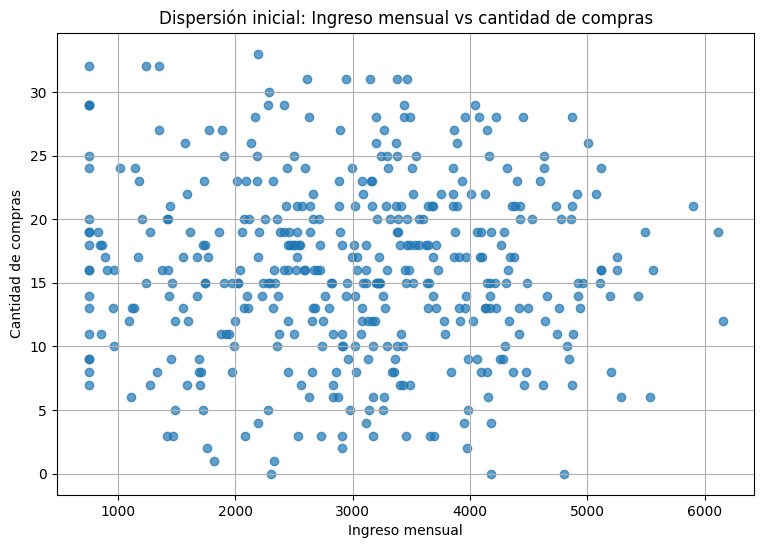

In [41]:
# ============================================================
# 14. Gráfica de dispersión sin clusters
# ============================================================

plt.figure(figsize=(9, 6))
plt.scatter(
    df_segmentado["IngresoMensual"],
    df_segmentado["CantidadCompras"],
    alpha=0.70
)
plt.title("Dispersión inicial: Ingreso mensual vs cantidad de compras")
plt.xlabel("Ingreso mensual")
plt.ylabel("Cantidad de compras")
plt.grid(True)
plt.show()

## 15. Gráfica de dispersión con clusters

Ahora coloreamos cada cliente según el cluster asignado.

Esta visualización ayuda a responder:

- ¿Los clusters se ven separados?
- ¿Hay mezcla entre grupos?
- ¿Hay clientes atípicos?
- ¿El resultado tiene sentido para explicar segmentos?

### Cuidado con la interpretación

Una gráfica de dispersión de dos variables no muestra toda la información del modelo, porque K-Means usó más variables.

Por eso, si los grupos se ven mezclados en dos dimensiones, no necesariamente significa que el modelo esté mal.  
Puede significar que la separación ocurre al combinar más variables.

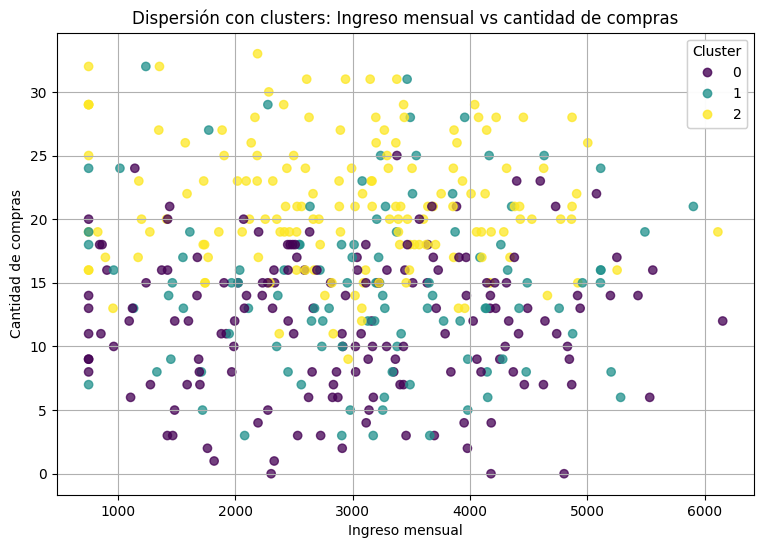

In [42]:
# ============================================================
# 15. Gráfica de dispersión con clusters
# ============================================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df_segmentado["IngresoMensual"],
    df_segmentado["CantidadCompras"],
    c=df_segmentado["Cluster"],
    alpha=0.75
)

plt.title("Dispersión con clusters: Ingreso mensual vs cantidad de compras")
plt.xlabel("Ingreso mensual")
plt.ylabel("Cantidad de compras")
plt.grid(True)

# Leyenda automática
legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()

## 16. Visualización con PCA

Como el clustering usó muchas variables, una gráfica con solo dos variables puede quedarse corta.

Para visualizar mejor, usamos **PCA**.

### ¿Qué hace PCA?

PCA resume muchas variables en dos componentes principales.

Esto permite graficar los datos en 2D y observar mejor la separación general de los clusters.

### Importante

PCA se usa aquí para visualizar, no para decir que los clusters son perfectos.

La gráfica ayuda a interpretar, pero la decisión debe combinarse con métricas y análisis de perfiles.

Varianza explicada por PC1: 12.22 %
Varianza explicada por PC2: 12.09 %
Varianza explicada total: 24.31 %


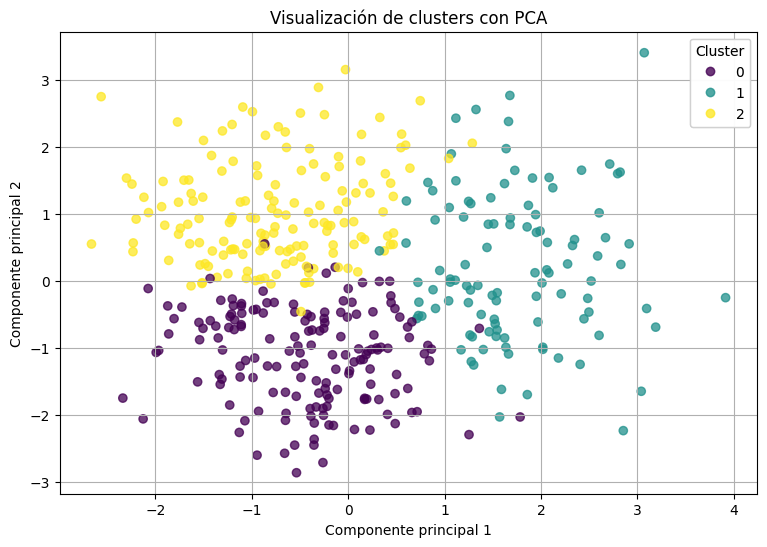

In [43]:
# ============================================================
# 16. Visualización 2D con PCA
# ============================================================

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_preparado)

df_pca = pd.DataFrame({
    "PC1": componentes[:, 0],
    "PC2": componentes[:, 1],
    "Cluster": clusters
})

varianza_explicada = pca.explained_variance_ratio_

print("Varianza explicada por PC1:", round(varianza_explicada[0] * 100, 2), "%")
print("Varianza explicada por PC2:", round(varianza_explicada[1] * 100, 2), "%")
print("Varianza explicada total:", round(varianza_explicada.sum() * 100, 2), "%")

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["Cluster"],
    alpha=0.75
)

plt.title("Visualización de clusters con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()

## 17. Perfilamiento de clusters

Después de crear los clusters, no basta con ver números.

Hay que interpretar qué caracteriza a cada grupo.

Para eso se calcula el promedio de variables numéricas por cluster.

Luego se pueden responder preguntas como:

- ¿Qué cluster compra más?
- ¿Qué cluster tiene más ingresos?
- ¿Qué cluster presenta más quejas?
- ¿Qué cluster tiene más visitas web?
- ¿Qué cluster lleva más tiempo como cliente?

In [44]:
# ============================================================
# 17. Perfilamiento numérico de clusters
# ============================================================

perfil_numerico = (
    df_segmentado
    .groupby("Cluster")[columnas_numericas]
    .mean()
    .round(2)
)

display(perfil_numerico)

,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados
Cluster,,,,,,,,,,
0,41.40,2957.65,11.91,5.17,26.98,0.61,34.61,9.97,7.26,3.10
1,37.08,3136.82,14.75,4.45,42.33,2.82,66.98,8.20,7.03,2.29
2,42.18,2957.60,21.22,5.35,71.67,0.81,36.44,9.37,6.95,2.16


## 18. Perfilamiento categórico

También es útil revisar la composición categórica de cada cluster.

Por ejemplo:

- segmento más frecuente;
- satisfacción más frecuente;
- ciudad predominante;
- canal preferido predominante.

Esto ayuda a convertir los clusters en perfiles comprensibles para el negocio.

In [45]:
# ============================================================
# 18. Perfilamiento categórico de clusters
# ============================================================

def moda_segura(serie):
    moda = serie.mode()
    if len(moda) == 0:
        return np.nan
    return moda.iloc[0]

perfil_categorico = (
    df_segmentado
    .groupby("Cluster")[columnas_nominales + columnas_ordinales]
    .agg(moda_segura)
)

display(perfil_categorico)

,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion
Cluster,,,,,
0,Bogota,Web,Urbana,Basico,Media
1,Bogota,Web,Urbana,Basico,Baja
2,Bogota,Web,Urbana,Basico,Media


# ASIGNAR NOMBRES INTERPRETATIVOS A CLUSTER
# Teniendo en cuenta los criterios de evaluación indicadas por el instructor, procedo a asignar nombres a los clusters, coherentes a los segmentos.

In [46]:
# ====================================================================
#18b. Interpretación basada en el perfilamiento realizado previamente 
# ====================================================================

nombres_segmentos = {
    0: "Clientes Activos",
    1: "Clientes en  Riesgo de Fuga",
    2: "Clientes Fidelizados"
}

df_segmentado["Segmento_Cluster"] = df_segmentado["Cluster"].map(nombres_segmentos)

print("Distribución por segmento:")
display(df_segmentado["Segmento_Cluster"].value_counts().to_frame("cantidad_clientes"))

display(df_segmentado[["ID_Cliente", "Cluster", "Segmento_Cluster"]].head(10))

Distribución por segmento:


,cantidad_clientes
Segmento_Cluster,
Clientes Activos,161
Clientes Fidelizados,153
Clientes en Riesgo de Fuga,106


,ID_Cliente,Cluster,Segmento_Cluster
0,CLI_0001,0,Clientes Activos
1,CLI_0002,2,Clientes Fidelizados
2,CLI_0003,2,Clientes Fidelizados
3,CLI_0004,1,Clientes en Riesgo de Fuga
4,CLI_0005,0,Clientes Activos
5,CLI_0006,1,Clientes en Riesgo de Fuga
6,CLI_0007,1,Clientes en Riesgo de Fuga
7,CLI_0008,0,Clientes Activos
8,CLI_0009,1,Clientes en Riesgo de Fuga
9,CLI_0010,0,Clientes Activos


## 19. Comparación externa con `Abandono` — uso opcional

Si el dataset tiene la variable `Abandono`, se puede usar después del clustering para analizar si los clusters tienen diferencias frente a esa variable.

### Importante

Esto no significa que `Abandono` haya sido usado para crear los grupos.

Solo se usa como una comparación externa para enriquecer la interpretación.

In [47]:
# ============================================================
# 19. Comparación externa con Abandono
# ============================================================

if "Abandono" in df_segmentado.columns:
    resumen_abandono = (
        df_segmentado
        .groupby("Segmento_Cluster")["Abandono"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "cantidad_clientes",
            "mean": "tasa_abandono_promedio"
        })
    )
    resumen_abandono["tasa_abandono_promedio"] = (
        resumen_abandono["tasa_abandono_promedio"] * 100
    ).round(2)

    display(resumen_abandono)
else:
    print("El dataset no contiene la variable Abandono.")

,cantidad_clientes,tasa_abandono_promedio
Segmento_Cluster,,
Clientes Activos,161,36.65
Clientes Fidelizados,153,33.99
Clientes en Riesgo de Fuga,106,65.09


## 20. Construcción de nombres interpretativos para los clusters

Después del perfilamiento, el analista puede asignar nombres descriptivos.

Ejemplo:

- **Cluster 0:** clientes de baja actividad.
- **Cluster 1:** clientes activos intermedios.
- **Cluster 2:** clientes de alto valor.

### Cuidado

Los nombres no deben asignarse antes de mirar los datos.  
Primero se revisan promedios, frecuencias y comportamiento; después se nombran.

In [48]:
# ============================================================
# 20. Tabla base para interpretación manual
# ============================================================

tabla_interpretacion = perfil_numerico.copy()

if "Abandono" in df_segmentado.columns:
    tabla_interpretacion = tabla_interpretacion.join(resumen_abandono)

display(tabla_interpretacion)

,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,cantidad_clientes,tasa_abandono_promedio
Cluster,,,,,,,,,,,,
0,41.40,2957.65,11.91,5.17,26.98,0.61,34.61,9.97,7.26,3.10,NaN,NaN
1,37.08,3136.82,14.75,4.45,42.33,2.82,66.98,8.20,7.03,2.29,NaN,NaN
2,42.18,2957.60,21.22,5.35,71.67,0.81,36.44,9.37,6.95,2.16,NaN,NaN


In [49]:
# ============================================================
# 20b. Tabla base para interpretación manual, aqui realice el cambio de la variable Cluster a Segmento_Cluster para que sea más interpretable.
# ============================================================

perfil_numerico_segmentos = df_segmentado.groupby("Segmento_Cluster").mean(numeric_only=True)

tabla_interpretacion = perfil_numerico_segmentos.copy()

if "Abandono" in df_segmentado.columns:
    tabla_interpretacion = tabla_interpretacion.join(resumen_abandono)

display(tabla_interpretacion)

,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Abandono,Cluster,cantidad_clientes,tasa_abandono_promedio
Segmento_Cluster,,,,,,,,,,,,,,
Clientes Activos,41.403727,2957.652174,11.906832,5.167702,26.975155,0.608696,34.608696,9.968944,7.262981,3.099379,0.366460,0.0,161,36.65
Clientes Fidelizados,42.183007,2957.601307,21.222222,5.352941,71.666667,0.810458,36.437908,9.366013,6.950850,2.156863,0.339869,2.0,153,33.99
Clientes en Riesgo de Fuga,37.084906,3136.820755,14.754717,4.452830,42.330189,2.820755,66.981132,8.198113,7.025943,2.292453,0.650943,1.0,106,65.09


## 21. Texto guía para justificar el número de clusters

El aprendiz puede usar esta estructura para redactar su justificación.

### Plantilla de justificación

> Se seleccionó `k = ___` después de comparar diferentes cantidades de clusters mediante el método del codo y el Silhouette Score. En el método del codo se observó que la disminución de la inercia empieza a estabilizarse alrededor de `k = ___`, lo que indica que agregar más clusters genera una mejora menor. Además, el Silhouette Score permitió evaluar la cohesión y separación de los grupos. Aunque el valor de Silhouette no siempre fue alto, se eligió este número de clusters porque permite interpretar perfiles diferenciados y útiles para el contexto del negocio. La decisión final fue tomada por el analista, combinando evidencia técnica, visualización mediante gráficas de dispersión y sentido práctico de la segmentación.

### Preguntas obligatorias

1. ¿Qué valor de `k` seleccionó?
2. ¿Qué mostró el método del codo?
3. ¿Qué mostró el Silhouette Score?
4. ¿La gráfica de dispersión muestra grupos separados o mezclados?
5. ¿Por qué ese número de clusters es útil para tomar decisiones?

In [50]:
# ============================================================
# 21. Generar resumen automático de apoyo para la justificación
# ============================================================

sil_k_elegido = float(
    tabla_silhouette.loc[tabla_silhouette["k"] == k_optimo, "silhouette_score"].iloc[0]
)

print("Resumen de apoyo para redactar la justificación")
print("------------------------------------------------")
print(f"K seleccionado: {k_optimo}")
print(f"K con mayor Silhouette Score: {k_mejor_silhouette}")
print(f"Silhouette del k seleccionado: {sil_k_elegido:.4f}")
print("\nRecuerde: si el k seleccionado no es el de mayor Silhouette, debe justificarse con interpretación del negocio.")

Resumen de apoyo para redactar la justificación
------------------------------------------------
K seleccionado: 3
K con mayor Silhouette Score: 2
Silhouette del k seleccionado: 0.0823

Recuerde: si el k seleccionado no es el de mayor Silhouette, debe justificarse con interpretación del negocio.


## 22. Exportar resultados

Finalmente, se exporta el dataset con la columna `Cluster`.

Este archivo puede ser usado para:

- análisis posterior;
- informe técnico;
- dashboard;
- recomendaciones comerciales;
- sustentación del proyecto.

In [51]:
# ============================================================
# 22. Exportar dataset segmentado y perfiles
# ============================================================

df_segmentado.to_csv("G4_dataset_segmentado_V2.csv", index=False, encoding="utf-8-sig")
perfil_numerico.to_csv("G4_perfil_numerico_clusters_V2.csv", encoding="utf-8-sig")
perfil_categorico.to_csv("G4_perfil_categorico_clusters_V2.csv", encoding="utf-8-sig")
tabla_comparativa_k.to_csv("G4_comparacion_k_codo_silhouette_V2.csv", index=False, encoding="utf-8-sig")

print("✅ Archivos exportados:")
print("- G4_dataset_segmentado_V2.csv")
print("- G4_perfil_numerico_clusters_V2.csv")
print("- G4_perfil_categorico_clusters_V2.csv")
print("- G4_comparacion_k_codo_silhouette_V2.csv")

✅ Archivos exportados:
- G4_dataset_segmentado_V2.csv
- G4_perfil_numerico_clusters_V2.csv
- G4_perfil_categorico_clusters_V2.csv
- G4_comparacion_k_codo_silhouette_V2.csv


# VISUALIZACIONES FINALES DE LOS ARCHIVOS EXPORTADOS

**VISUALIZACIÓN DEL DATASET SEGMENTADO**

In [52]:
# ── Vista previa: dataset segmentado ──
print("=== Dataset segmentado (primeras 10 filas) ===")
display(df_segmentado[["ID_Cliente", "Cluster", "Segmento_Cluster"]].head(10))

=== Dataset segmentado (primeras 10 filas) ===


,ID_Cliente,Cluster,Segmento_Cluster
0,CLI_0001,0,Clientes Activos
1,CLI_0002,2,Clientes Fidelizados
2,CLI_0003,2,Clientes Fidelizados
3,CLI_0004,1,Clientes en Riesgo de Fuga
4,CLI_0005,0,Clientes Activos
5,CLI_0006,1,Clientes en Riesgo de Fuga
6,CLI_0007,1,Clientes en Riesgo de Fuga
7,CLI_0008,0,Clientes Activos
8,CLI_0009,1,Clientes en Riesgo de Fuga
9,CLI_0010,0,Clientes Activos


**VIZUALIZACION DEL PERFIL NUMÉRICO**

In [53]:
# ── Vista previa: perfil numérico ──
print("=== Perfil numérico por cluster ===")
display(pd.read_csv("G4_perfil_numerico_clusters_V2.csv", index_col=0))

=== Perfil numérico por cluster ===


,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados
Cluster,,,,,,,,,,
0,41.40,2957.65,11.91,5.17,26.98,0.61,34.61,9.97,7.26,3.10
1,37.08,3136.82,14.75,4.45,42.33,2.82,66.98,8.20,7.03,2.29
2,42.18,2957.60,21.22,5.35,71.67,0.81,36.44,9.37,6.95,2.16


**VISUALIZACIÓN DEL PERFIL CATEGÓRICO**

In [54]:
# ── Vista previa: perfil categórico ──
print("=== Perfil categórico por cluster ===")
display(pd.read_csv("G4_perfil_categorico_clusters_V2.csv", index_col=0))

=== Perfil categórico por cluster ===


,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion
Cluster,,,,,
0,Bogota,Web,Urbana,Basico,Media
1,Bogota,Web,Urbana,Basico,Baja
2,Bogota,Web,Urbana,Basico,Media


**VISUALIZACIÓN DE COMPARACIÓN CODO + SILHOUETTE**

In [55]:
# ── Vista previa: comparación codo + silhouette ──
print("=== Comparación k — codo y Silhouette Score ===")
display(pd.read_csv("G4_comparacion_k_codo_silhouette_V2.csv"))

=== Comparación k — codo y Silhouette Score ===


,k,inercia,reduccion_inercia,reduccion_porcentual,silhouette_score
0,2,4974.433682,NaN,NaN,0.098598
1,3,4615.081176,359.352506,7.22,0.082294
2,4,4422.226149,192.855028,4.18,0.072314
3,5,4261.723426,160.502722,3.63,0.071036
4,6,4139.848592,121.874834,2.86,0.065339
5,7,4029.712251,110.136340,2.66,0.066207
6,8,3939.328466,90.383785,2.24,0.066095
7,9,3852.598338,86.730128,2.20,0.064960
8,10,3784.102061,68.496277,1.78,0.063710


## 23. Actividad final del aprendiz

El aprendiz debe entregar:

1. Notebook ejecutado.
2. Dataset segmentado con columna `Cluster`.
3. Tabla de comparación de `k`.
4. Gráfica del método del codo.
5. Gráfica del Silhouette Score.
6. Gráfica de dispersión con clusters.
7. Visualización PCA.
8. Perfilamiento de clusters.
9. Justificación escrita de la cantidad de clusters.
10. Conclusiones y recomendaciones.

### Preguntas de análisis

Responda en su informe:

1. ¿Por qué en esta guía no se usa variable objetivo `y`?
2. ¿Quién determina la cantidad final de clusters?
3. ¿Qué diferencia hay entre método del codo y Silhouette Score?
4. ¿Qué variables parecen diferenciar mejor los clusters?
5. ¿Qué limitaciones tiene el resultado?
6. ¿Qué decisiones podría tomar una empresa con estos segmentos?

---

## 24. Cierre conceptual

La segmentación con aprendizaje no supervisado no busca “adivinar una respuesta correcta”.

Busca descubrir patrones.

Por eso, el resultado debe evaluarse con cuidado.

Una buena solución de clustering debe ser:

- técnicamente razonable;
- visualmente interpretable;
- útil para el contexto;
- explicable en lenguaje claro;
- documentada con evidencias.

> En clustering, el modelo propone grupos; el analista les da sentido.